In [1]:
# ==== Cell 1: Imports ====
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from dataclasses import dataclass

from Agents.DQAgent import DQAgent
from Agents.CADRLAgent import CADRLStyleAgent
from Environments.GoalChasing.goal_chasing_env import GoalChasingEnvironment
from Environments.GoalChasing.board import Board
from Environments.GoalChasing.robot import Robot
from Environments.GoalChasing.goal import Goal
from Agents.DQAgent import DQAgent
from Agents.CADRLAgent import CADRLStyleAgent
from GameRunner import GameRunner
from Runners.GoalChasing_QLearning.base import build_model

map_fonts = {
   'title': {'fontsize': 20, 'fontweight': 'bold', 'color': 'black'},
   'xlabel': {'fontsize': 15, 'fontweight': 'medium', 'color': 'black'},
   'ylabel': {'fontsize': 15, 'fontweight': 'medium', 'color': 'black'},
   'legend': {'fontsize': 11, 'loc': 'upper right'},
}

In [30]:
# ==== Cell 2: Load trained checkpoints ====
state_dim = (2 * 10 + 1) ** 2 * 2 + 2
action_dim = 8

agents = {
    'DQN (Greedy)_curr': DQAgent(state_dim, action_dim),
    'CADRL-Style_curr': CADRLStyleAgent(state_dim, action_dim),
    'DQN (Greedy)_single': DQAgent(state_dim, action_dim),
    'CADRL-Style_single': CADRLStyleAgent(state_dim, action_dim),
}
agents['DQN (Greedy)_curr'].load_model(r'results\DQN_(Greedy)-curr\DQN_(Greedy)_9\agent2_epoch_final')
agents['CADRL-Style_curr'].load_model(r'results\CADRL-Style-curr\CADRL-Style_9\agent2_epoch_final')
agents['DQN (Greedy)_single'].load_model(r'results\DQN_(Greedy)-single_1\agent2_epoch_final')
agents['CADRL-Style_single'].load_model(r'results\CADRL-Style-single_1\agent2_epoch_final')

In [46]:
def choose_action_for_agent(agent, state, robot, goal, board):
    if isinstance(agent, CADRLStyleAgent):
        other_robots = [r for r, g, _ in board.players if r.id != robot.id]
        return agent.choose_action(state, robot=robot, goal=goal, other_robots=other_robots)
    return agent.choose_action(state)

In [18]:
# ==== Cell 3: Canonical scenario builder ====
class ScenarioBuilder:
    """Constructs fixed, symmetric (robot, goal) placements for qualitative eval."""

    @staticmethod
    def two_robot_swap(board_size=100, offset=30):
        c = board_size / 2
        robots = [(c - offset, c), (c + offset, c)]
        goals = [(c + offset, c), (c - offset, c)]
        return robots, goals

    @staticmethod
    def n_robot_circle_swap(n, board_size=100, radius=35):
        c = board_size / 2
        angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
        robots = [(c + radius * np.cos(a), c + radius * np.sin(a)) for a in angles]
        goals = [(c - radius * np.cos(a), c - radius * np.sin(a)) for a in angles]  # directly across
        return robots, goals

    @staticmethod
    def star_cross(board_size=100, offset=30):
        """4 robots in a '+' arrangement, each goal 90 deg to their right."""
        c = board_size / 2
        robots = [(c, c - offset), (c + offset, c), (c, c + offset), (c - offset, c)]  # N, E, S, W
        goals = [(c + offset, c), (c, c + offset), (c - offset, c), (c, c - offset)]   # each rotated +90
        return robots, goals


SCENARIOS = {
    '2_robot_swap': lambda: ScenarioBuilder.two_robot_swap(),
    '6_robot_circle_swap': lambda: ScenarioBuilder.n_robot_circle_swap(n=6),
    '4_robot_star': lambda: ScenarioBuilder.star_cross(),
}

In [51]:
# ==== Cell 4: Inject scenario into board + eval-mode rollout ====
def build_scenario_board(robot_positions, goal_positions, board_size=100, view_threshold=10, closeness_threshold=4):
    board = Board(size=board_size)
    board.max_players = len(robot_positions)
    board.players = []
    for i, ((rx, ry), (gx, gy)) in enumerate(zip(robot_positions, goal_positions)):
        robot = Robot(id=i + 1, x=rx, y=ry, v=1, dir=0,
                      view_threshold=view_threshold, closeness_threshold=closeness_threshold)
        goal = Goal(id=i + 1, x=gx, y=gy)
        board.add_robot(robot, goal, None)
    return board

def rollout_scenario(agent, board, board_size=100, view_threshold=10,
                      closeness_threshold=4, max_steps=200):
    config = {'board_size': board_size, 'view_threshold': view_threshold,
              'closeness_threshold': closeness_threshold, 'num_robots': board.max_players,
              'reset_on_goal': False}
    env = GoalChasingEnvironment(board, {f'agent{i+1}': agent for i in range(board.max_players)}, config=config)
    env._update_board()

    old_epsilon = agent.epsilon
    agent.epsilon = 0.01

    all_ids = [r.id for r, g, _ in board.players]
    trajectories = {rid: [(r.x, r.y)] for rid, (r, g, _) in zip(all_ids, board.players)}
    collision_events = []
    active_ids = set(all_ids)

    for step in range(max_steps):
        states = env.get_states()
        actions = {name: agent.choose_action(s) for name, s in states.items()}
        env.execute_actions(actions)

        current_ids = {r.id for r, g, _ in env.board.players}
        for robot, goal, _ in env.board.players:
            trajectories[robot.id].append((robot.x, robot.y))
            if robot.check_collisions() > 0:
                collision_events.append((step, robot.id, robot.x, robot.y))

        active_ids &= current_ids  # robots removed (reached goal) simply stop appending
        if not env.board.players:
            break

    agent.epsilon = old_epsilon
    return trajectories, collision_events

In [52]:
# ==== Cell 5: Run all scenarios for both agents ====
results = {}
for scenario_name, builder in SCENARIOS.items():
    robot_pos, goal_pos = builder()
    results[scenario_name] = {}
    for agent_name, agent in agents.items():
        board = build_scenario_board(robot_pos, goal_pos)
        traj, collisions = rollout_scenario(agent, board)
        results[scenario_name][agent_name] = {
            'trajectories': traj, 'collisions': collisions,
            
            'goals': goal_pos, 'starts': robot_pos,
        }
        print(f"{scenario_name} / {agent_name}: {len(collisions)} collision events, "
              f"{len(traj[1])} steps")

2_robot_swap / DQN (Greedy)_curr: 4 collision events, 61 steps
2_robot_swap / CADRL-Style_curr: 0 collision events, 65 steps
2_robot_swap / DQN (Greedy)_single: 2 collision events, 60 steps
2_robot_swap / CADRL-Style_single: 0 collision events, 76 steps
6_robot_circle_swap / DQN (Greedy)_curr: 10 collision events, 72 steps
6_robot_circle_swap / CADRL-Style_curr: 14 collision events, 73 steps
6_robot_circle_swap / DQN (Greedy)_single: 25 collision events, 72 steps
6_robot_circle_swap / CADRL-Style_single: 4 collision events, 201 steps
4_robot_star / DQN (Greedy)_curr: 0 collision events, 36 steps
4_robot_star / CADRL-Style_curr: 0 collision events, 32 steps
4_robot_star / DQN (Greedy)_single: 0 collision events, 30 steps
4_robot_star / CADRL-Style_single: 0 collision events, 61 steps


In [53]:
def plot_scenario(scenario_name, agent_name, data, board_size=100):
    fig, ax = plt.subplots(figsize=(7, 7))
    n_robots = len(data['trajectories'])
    cmap = plt.get_cmap('tab10', max(n_robots, 3))

    for i, (robot_id, points) in enumerate(data['trajectories'].items()):
        pts = np.array(points)
        color = cmap(i)
        ax.plot(pts[:, 0], pts[:, 1], color=color, alpha=0.6, linewidth=1.5, zorder=2)
        ax.plot([pts[0, 0], data['goals'][i][0]], [pts[0, 1], data['goals'][i][1]],
                color=color, linestyle=':', alpha=0.3, linewidth=1, zorder=1)  # intended straight-line path
        ax.scatter(*pts[0], color=color, marker='o', s=100, edgecolor='k', zorder=3)
        ax.scatter(*data['goals'][i], color=color, marker='*', s=220, edgecolor='k', zorder=3)
        ax.annotate(str(robot_id), pts[0], textcoords="offset points", xytext=(6, 6), fontsize=9)

    if data['collisions']:
        coll = np.array([(x, y) for _, _, x, y in data['collisions']])
        ax.scatter(coll[:, 0], coll[:, 1], color='red', marker='x', s=90, linewidth=2,
                   zorder=4)

    # Proxy legend entries, decoupled from per-robot color
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=9,
               markeredgecolor='k', label='Start'),
        Line2D([0], [0], marker='*', color='gray', linestyle='None', markersize=13,
               markeredgecolor='k', label='Goal'),
    ]
    if data['collisions']:
        legend_elements.append(
            Line2D([0], [0], marker='x', color='red', linestyle='None', markersize=9,
                   label='Collision'))

    ax.set_xlim(0, board_size)
    ax.set_ylim(0, board_size)
    ax.set_aspect('equal')
    n_collisions = len(data['collisions'])
    ax.set_title(f'{scenario_name} — {agent_name} ({n_collisions} collision event(s))',
                 fontdict=map_fonts['title'])
    ax.set_xlabel('X', fontdict=map_fonts['xlabel'])
    ax.set_ylabel('Y', fontdict=map_fonts['ylabel'])
    ax.legend(handles=legend_elements, **map_fonts['legend'])
    plt.tight_layout()
    plt.savefig(f'scenario_{scenario_name}_{agent_name.replace(" ", "_").replace("(", "").replace(")", "")}.png',
                dpi=200)
    plt.show()

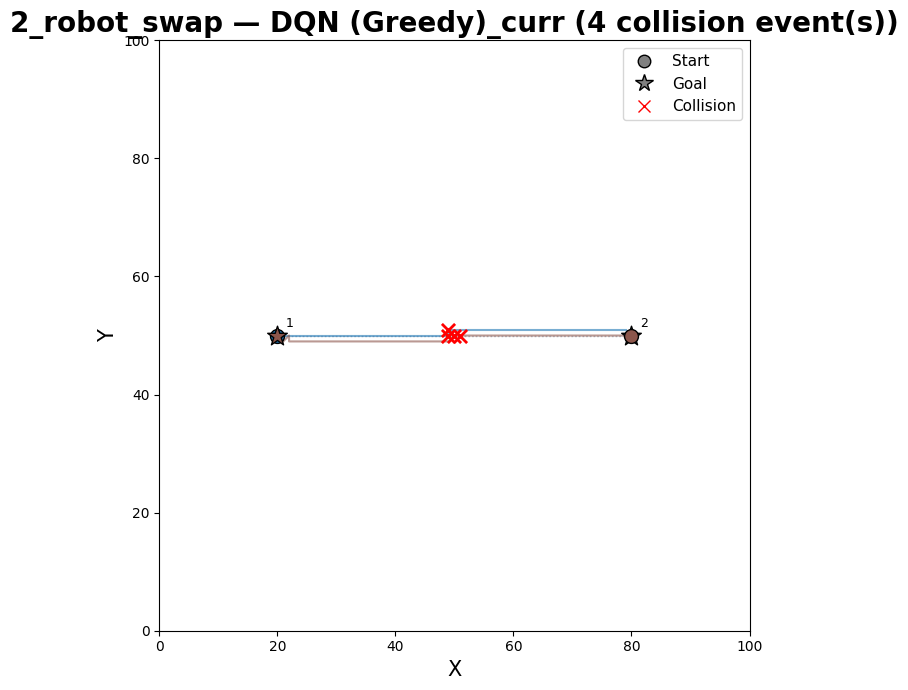

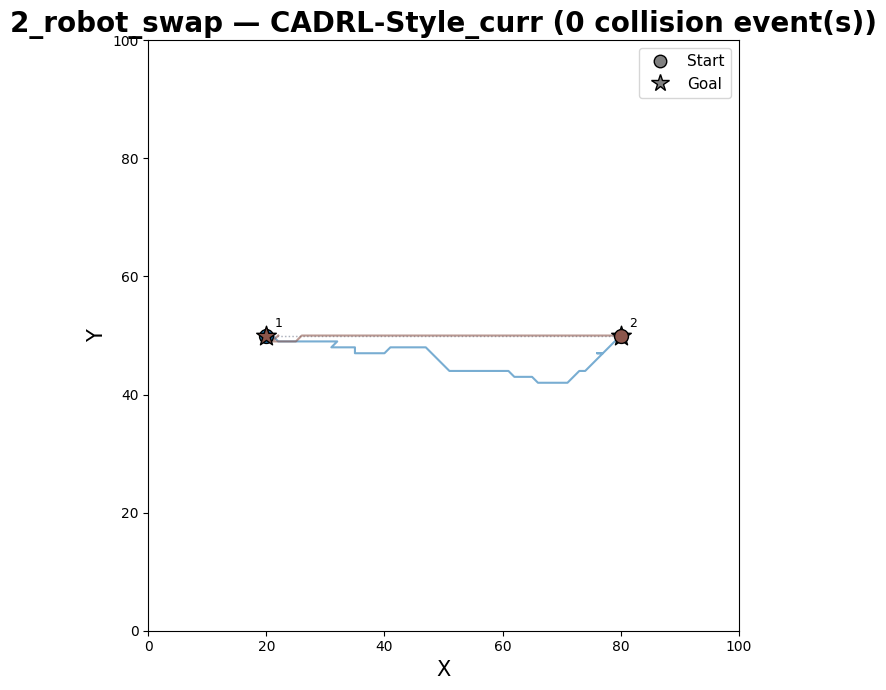

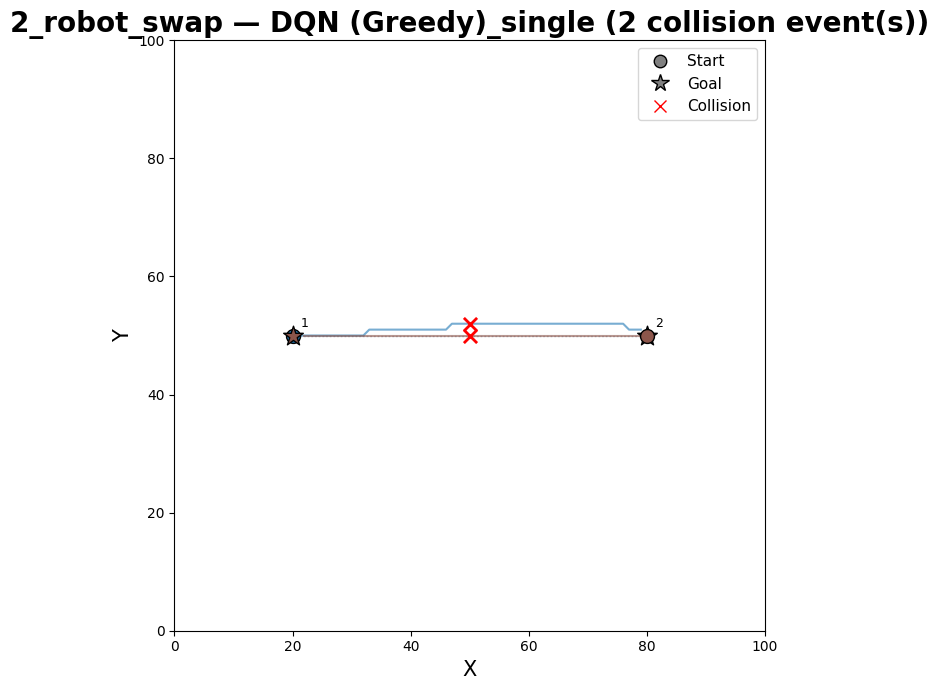

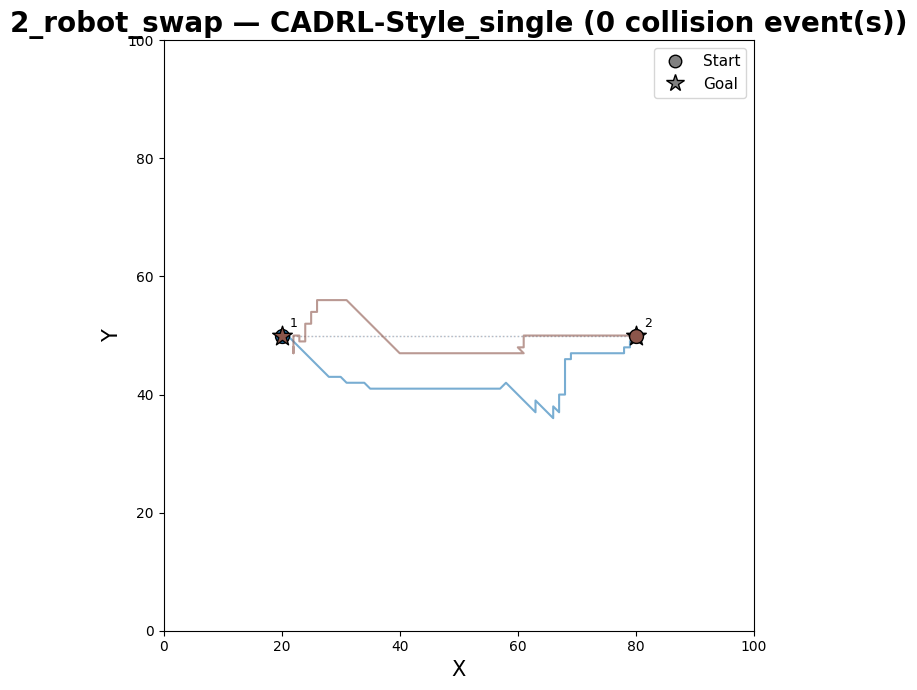

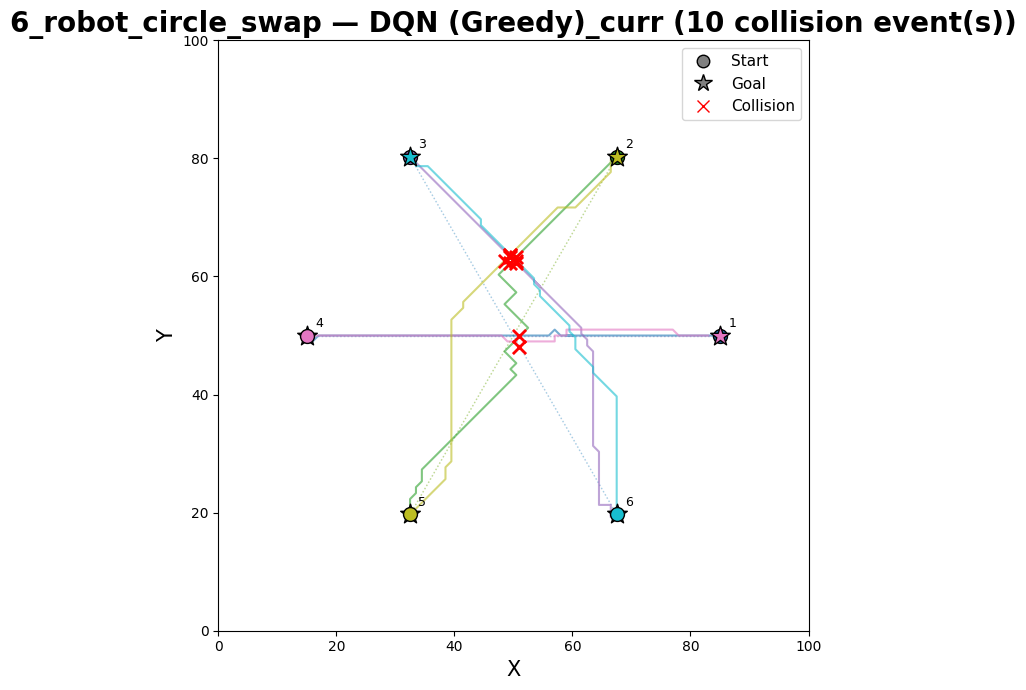

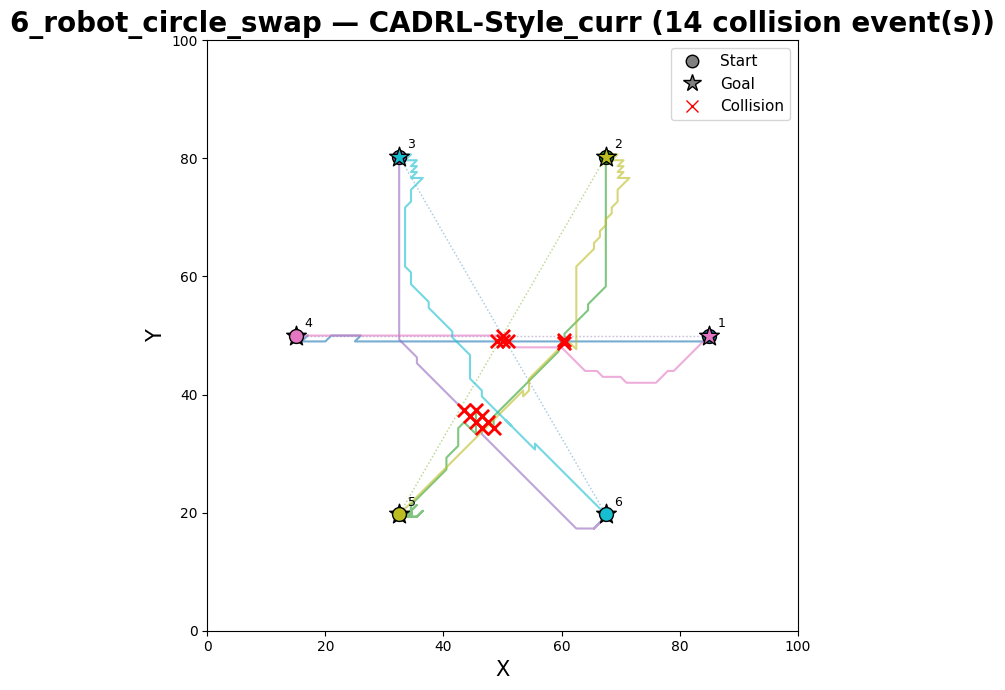

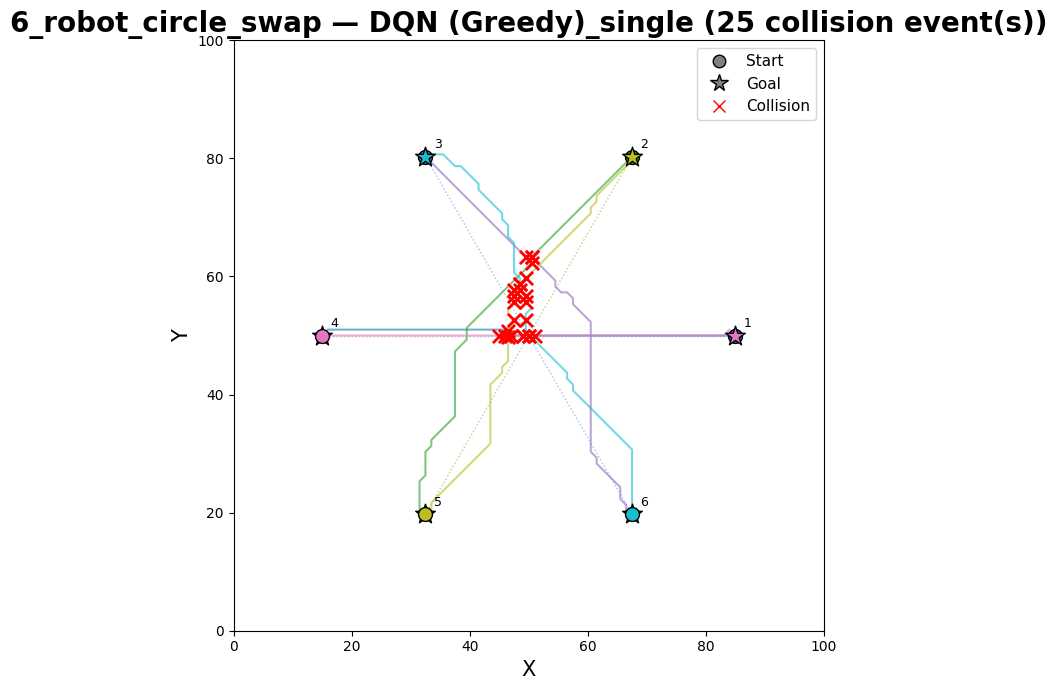

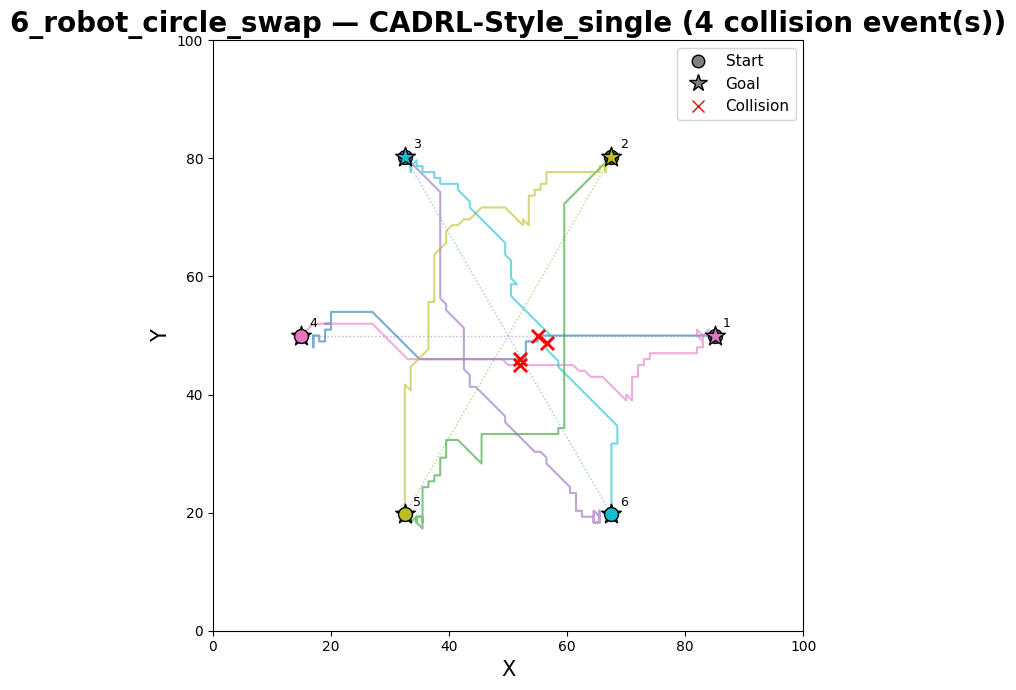

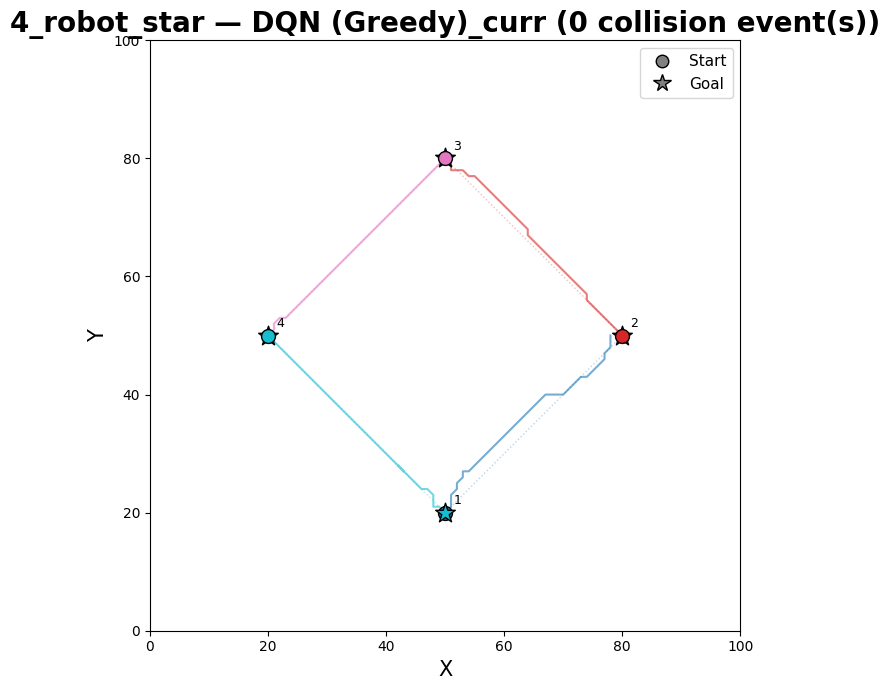

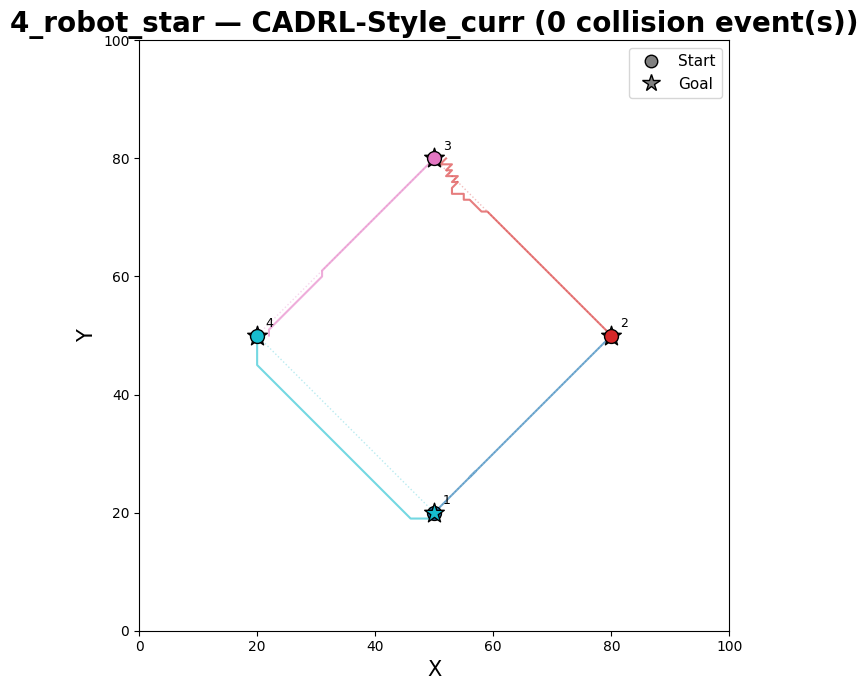

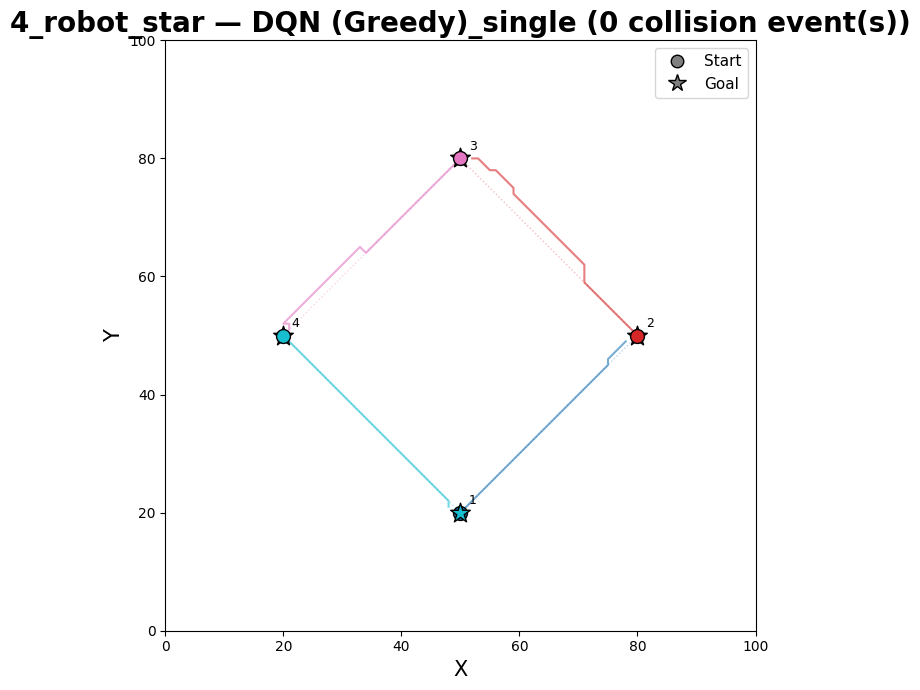

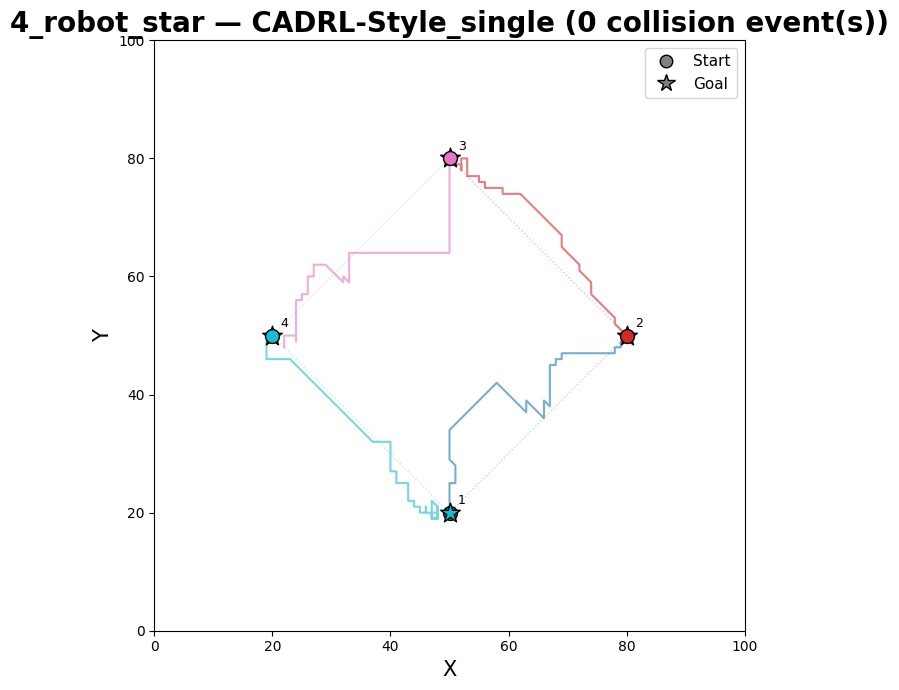

In [54]:
# ==== Cell 7: Generate all plots ====
for scenario_name, agent_results in results.items():
    for agent_name, data in agent_results.items():
        plot_scenario(scenario_name, agent_name, data)

In [42]:
# ==== Cell 8: Extended rollout that logs motion-performance metrics ====
def rollout_scenario_with_metrics(agent, board, board_size=100, view_threshold=10,
                                   closeness_threshold=4, max_steps=200):
    config = {'board_size': board_size, 'view_threshold': view_threshold,
              'closeness_threshold': closeness_threshold, 'num_robots': board.max_players,
              'reset_on_goal': False}
    env = GoalChasingEnvironment(board, {f'agent{i+1}': agent for i in range(board.max_players)}, config=config)
    env._update_board()

    old_epsilon = agent.epsilon
    agent.epsilon = 0.01

    all_ids = [r.id for r, g, _ in board.players]
    goals_by_id = {r.id: g for r, g, _ in board.players}
    trajectories = {rid: [(r.x, r.y)] for rid, (r, g, _) in zip(all_ids, board.players)}
    collision_events = []

    # per-step aggregate logs
    mean_dist_to_goal = []
    min_inter_robot_dist = []
    cumulative_collisions = []
    completion_ratio = []
    total_collisions_so_far = 0
    n_total = len(all_ids)

    for step in range(max_steps):
        states = env.get_states()
        actions = {name: agent.choose_action(s) for name, s in states.items()}
        env.execute_actions(actions)

        active_robots = [(r, g) for r, g, _ in env.board.players]
        for robot, goal, _ in env.board.players:
            trajectories[robot.id].append((robot.x, robot.y))
            if robot.check_collisions() > 0:
                collision_events.append((step, robot.id, robot.x, robot.y))

        # distance-to-goal, averaged over currently-active robots
        if active_robots:
            dists_to_goal = [r.get_dist(g)[0] for r, g in active_robots]
            mean_dist_to_goal.append(np.mean(dists_to_goal))
        else:
            mean_dist_to_goal.append(0.0)

        # min pairwise inter-robot distance among active robots
        positions = np.array([[r.x, r.y] for r, g in active_robots])
        if len(positions) >= 2:
            from scipy.spatial.distance import pdist
            min_inter_robot_dist.append(pdist(positions).min())
        else:
            min_inter_robot_dist.append(np.nan)  # undefined with <2 active robots

        # cumulative collision events up to this step
        total_collisions_so_far = sum(1 for (s, *_ ) in collision_events if s <= step)
        cumulative_collisions.append(total_collisions_so_far)

        # completion ratio = fraction of robots that have reached goal (i.e. removed from board)
        n_active = len(env.board.players)
        completion_ratio.append((n_total - n_active) / n_total)

        if not env.board.players:
            break

    agent.epsilon = old_epsilon
    return {
        'trajectories': trajectories,
        'collisions': collision_events,
        'mean_dist_to_goal': mean_dist_to_goal,
        'min_inter_robot_dist': min_inter_robot_dist,
        'cumulative_collisions': cumulative_collisions,
        'completion_ratio': completion_ratio,
    }

In [43]:
# ==== Cell 9: Run all scenarios for all 4 agents ====
motion_results = {}
for scenario_name, builder in SCENARIOS.items():
    robot_pos, goal_pos = builder()
    motion_results[scenario_name] = {}
    for agent_name, agent in agents.items():
        board = build_scenario_board(robot_pos, goal_pos)
        data = rollout_scenario_with_metrics(agent, board)
        data['goals'] = goal_pos
        data['starts'] = robot_pos
        motion_results[scenario_name][agent_name] = data
        print(f"{scenario_name} / {agent_name}: {len(data['collisions'])} collisions, "
              f"{len(data['mean_dist_to_goal'])} steps to finish")

2_robot_swap / DQN (Greedy)_curr: 2 collisions, 62 steps to finish
2_robot_swap / CADRL-Style_curr: 0 collisions, 65 steps to finish
2_robot_swap / DQN (Greedy)_single: 4 collisions, 60 steps to finish
2_robot_swap / CADRL-Style_single: 0 collisions, 110 steps to finish
6_robot_circle_swap / DQN (Greedy)_curr: 28 collisions, 76 steps to finish
6_robot_circle_swap / CADRL-Style_curr: 10 collisions, 93 steps to finish
6_robot_circle_swap / DQN (Greedy)_single: 25 collisions, 70 steps to finish
6_robot_circle_swap / CADRL-Style_single: 8 collisions, 200 steps to finish
4_robot_star / DQN (Greedy)_curr: 0 collisions, 36 steps to finish
4_robot_star / CADRL-Style_curr: 0 collisions, 41 steps to finish
4_robot_star / DQN (Greedy)_single: 0 collisions, 37 steps to finish
4_robot_star / CADRL-Style_single: 0 collisions, 150 steps to finish


In [44]:
# ==== Cell 10: Plot the 4 motion-performance curves per scenario ====
def plot_motion_curves(scenario_name, agent_results):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    metrics = [
        ('mean_dist_to_goal', 'Mean Distance to Goal', axes[0, 0]),
        ('min_inter_robot_dist', 'Min Inter-Robot Distance', axes[0, 1]),
        ('cumulative_collisions', 'Cumulative Collisions', axes[1, 0]),
        ('completion_ratio', 'Completion Ratio', axes[1, 1]),
    ]
    colors = {'DQN (Greedy)_curr': 'tab:blue', 'CADRL-Style_curr': 'tab:green',
              'DQN (Greedy)_single': 'tab:orange', 'CADRL-Style_single': 'tab:red'}

    for key, label, ax in metrics:
        for agent_name, data in agent_results.items():
            values = data[key]
            ax.plot(range(len(values)), values, label=agent_name,
                    color=colors.get(agent_name), alpha=0.85)
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.set_xlabel('Step')
        ax.set_ylabel(label)

    axes[0, 0].legend(fontsize=8, loc='upper right')
    fig.suptitle(f'Motion-Performance Curves — {scenario_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'motion_curves_{scenario_name}.png', dpi=200)
    plt.show()

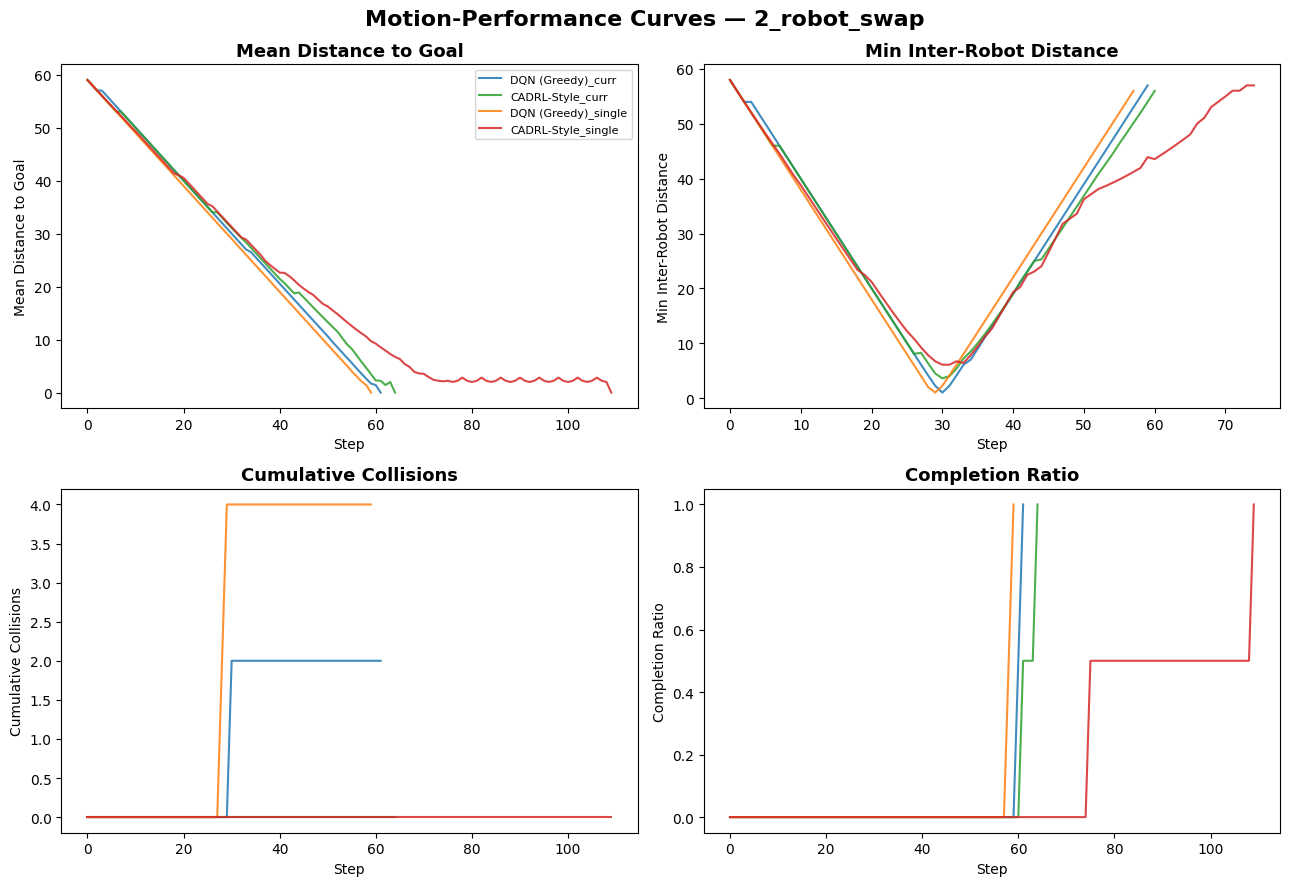

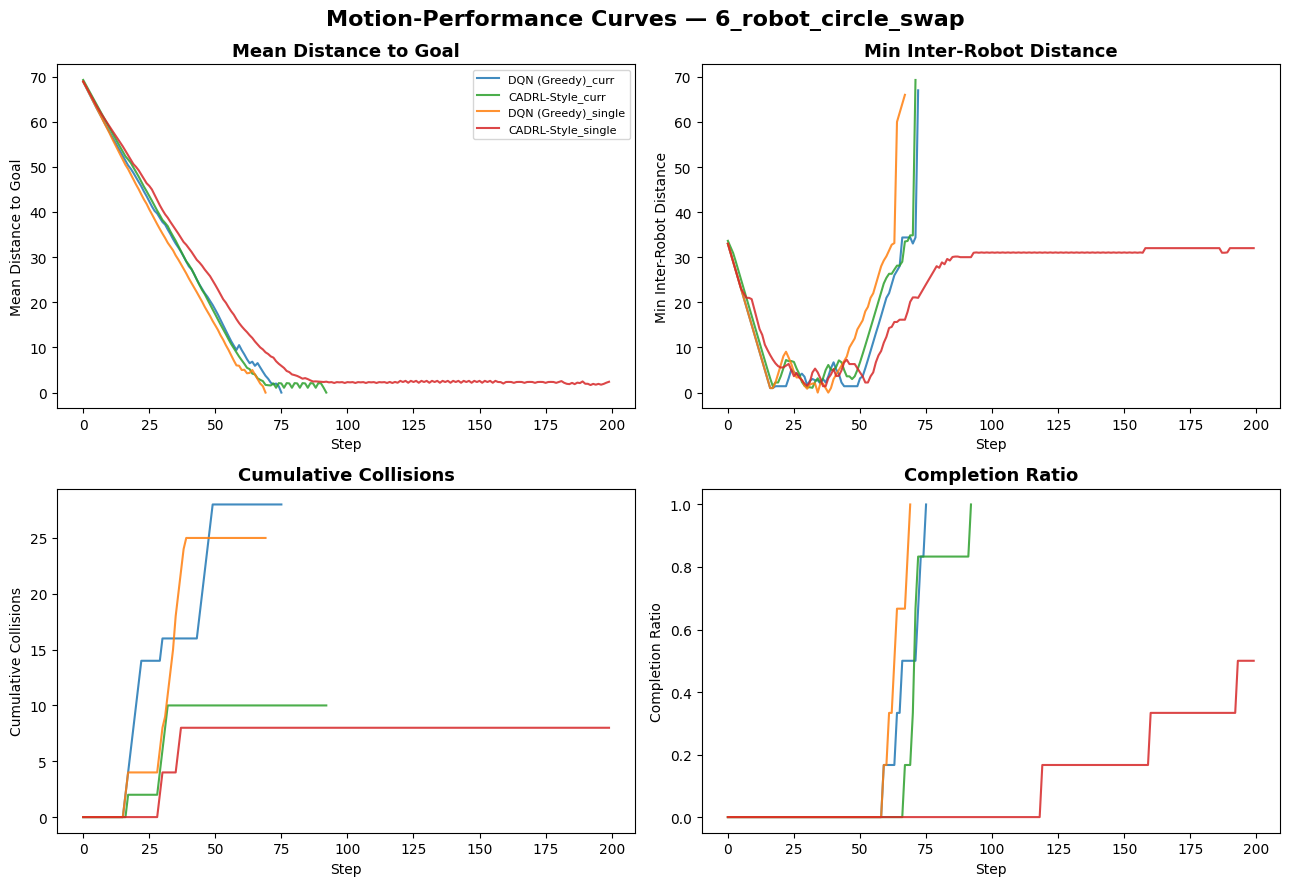

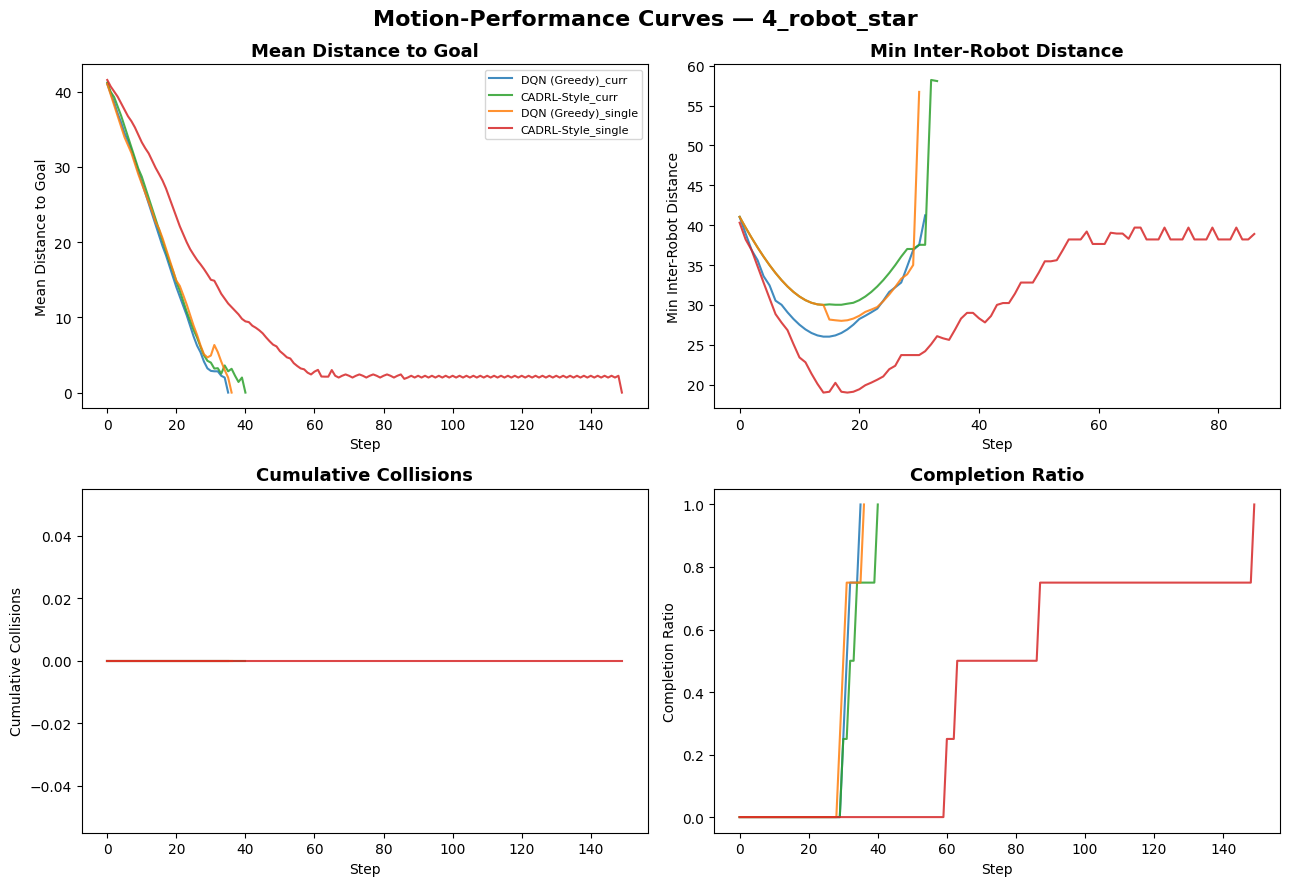

In [45]:
for scenario_name, agent_results in motion_results.items():
    plot_motion_curves(scenario_name, agent_results)